# Logistic Regression

Hồi quy logistic là một trong những thuật toán Machine Learning đơn giản và được sử dụng phổ biến nhất cho các bài toán phân loạn 2 lớp. Nó rất dễ thực hiện và có thể được sử dụng làm mô hình cơ sở cho bất kỳ bài toán phân loại nhị phân nào.

Hồi quy logistic có thể được sử dụng cho các vấn đề phân loại khác nhau như phát hiện thư rác, dự đoán bệnh, dự đoán khách hàng rời bỏ, dự đoạn xác suất sử dụng dịch vụ của khách hàng.

## Phân loại mô hình Logistic Regression

Binary Logistic Regression: Biến mục tiêu chỉ có hai kết quả có thể xảy ra là Thư rác hoặc Không phải Thư rác, Ung thư hoặc Không Ung thư.

Multinomial Logistic Regression: Biến mục tiêu có nhiều kết quả có thể xảy ra, ví dụ như dự đoán loại Rượu tương ứng.

## Xây dựng Logistic Regression Model bằng thư viện Scikit-learn

Hãy xây dựng mô hình dự đoán bệnh tiểu đường bằng cách sử dụng Phân loại hồi quy logistic.

Bạn có thể download dữ liệu ở đây: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

### Loading Data

In [1]:
#import pandas
import pandas as pd
# load dataset
diabetes = pd.read_csv("L10_datasets/diabetes.csv")

In [2]:
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Tách các biến dự đoán và biến mục tiêu

In [3]:
# Tách các biến dự đoán và biến mục tiêu
feature_cols = ["Pregnancies", "Glucose", "BloodPressure", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
X = diabetes[feature_cols] # biến dự đoá
y = diabetes.Outcome # biến mục tiêu

### Chia dữ liệu thành 2 tập Dataset: 1 dành cho huấn luyện mô hình, 1 dành cho thử nghiệm mô hình

Chúng ta sẽ sử dụng thư viện `train_test_split()` để chia dữ liệu thành 2 tập: train và test. 

In [4]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)

Ở đây, Dataset được chia thành hai phần theo tỷ lệ 75:25. Điều đó có nghĩa là 75% dữ liệu sẽ được sử dụng để đào tạo mô hình và 25% để thử nghiệm mô hình.

### Phát triển và dự đoán mô hình

**Bước 1:** import module `LogisticRegression` và tạo một LogisticRegression object bằng hàm `LogisticRegression()`.

**Bước 2:** Huấn luyện mô hình trên tập traon bằng cách sử dụng `fit()` và thực hiện dự đoán trên tập test bằng cách sử dụng `.predict()`

In [5]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=1000)

# fit the model with train data
logreg.fit(X_train,y_train)

# predict with test data
y_pred=logreg.predict(X_test)

### Đánh giá mô hình bằng Confusion Matrix

Confusion matrix thường được sử dụng để đánh giá các bài toán phân loại.

In [6]:
# import the metrics class
from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

array([[118,  12],
       [ 26,  36]])

Tại đây, bạn có thể thấy ma trận confusion matrix ở dạng đối tượng mảng. Kích thước của ma trận này là 2*2 vì mô hình này là phân loại nhị phân. Bạn có hai lớp 0 và 1. 

Giá trị đường chéo thể hiện dự đoán chính xác, trong khi các phần tử không nằm trong đường đường chéo là dự đoán không chính xác. 

Kết quả cho thấy 118 và 36 là dự đoán chính xác và 26 và 12 là dự đoán không chính xác.



### Trực quan hoá Confusion Matrix bằng biểu đồ Heatmap

Hãy trực quan hoá kết quả của mô hình dưới dạng một confusion matrix sử dụng matplotlib và seaborn.

In [7]:
# import required modules
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Text(0.5, 427.9555555555555, 'Predicted label')

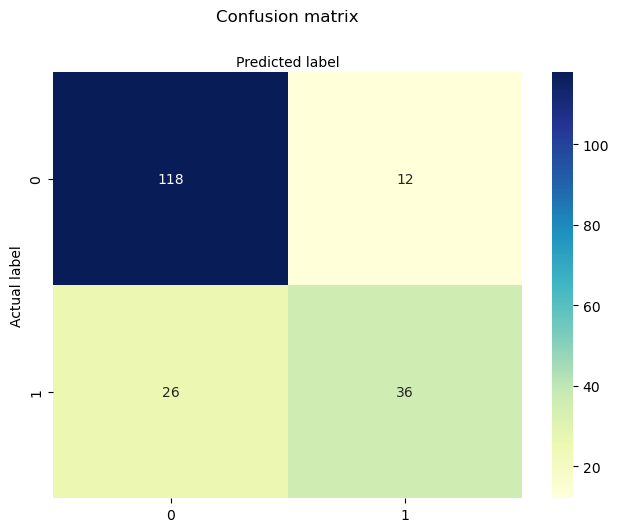

In [8]:
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

### Các chỉ số đánh giá Confusion Matrix 

Đánh giá mô hình sử dụng các chỉ số đánh giá như accuracy, precision, và recall.

In [9]:
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
print("Precision:",metrics.precision_score(y_test, y_pred))
print("Recall:",metrics.recall_score(y_test, y_pred))

Accuracy: 0.8020833333333334
Precision: 0.75
Recall: 0.5806451612903226


Chúng ta có độ chính xác của mô hình là 80%.

**Precision**: có nghĩa là độ chính xác, tức là mô hình chính xác đến mức nào. Nói cách khác, khi một mô hình đưa ra dự đoán, mức độ thường xuyên dự đoán đó đúng. Trong bài toán này, khi mô hình Hồi quy Logistic dự đoán bệnh nhân sẽ mắc bệnh tiểu đường, thì có tới 75% trường hợp dự đoán chính xác là sẽ mắc bệnh tiểu đường.

**Recall**: Mô hình chỉ có thể dự đoán chính xác được 58% số bệnh nhân mắc bệnh trong bộ dữ liệu test. Còn 42% còn lại mô hình dự đoán sai khi dự đoán bệnh nhân không mắc bệnh tiểu đường, nhưng thực tế số liệu ghi nhận trong tập test cho rằng bệnh nhân lại mắc bệnh tiểu đường.

### ROC Curve

ROC (Receiver operating characteristic) là một đồ thị được sử dụng khá phổ biến trong validation các model phân loại nhị phân. Đường cong này được tạo ra bằng cách biểu diễn tỷ lệ dự báo true positive rate (TPR) dựa trên tỷ lệ dự báo failse positive rate (FPR) tại các ngưỡng Threshold khác nhau.


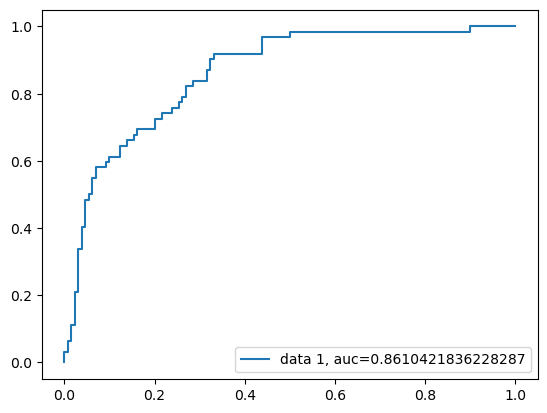

In [10]:
y_pred_proba = logreg.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

Chỉ số AUC cho mô hình này là 0.86. Khi chỉ số AUC = 1, có nghĩa là mô hình phân loại hoàn hảo. Khi số AUC = 0.5, mô hình phân loại không thực sự tốt.

### Ưu điểm của mô hình Logistic Regression


- Hiệu quả và đơn giản, không yêu cầu khả năng tính toán cao
- Dễ thực hiện, dễ hiểu
- Được sử dụng rộng rãi bởi các nhà phân tích và nhà khoa học dữ liệu


###  Nhược điểm của mô hình Logistic Regression

- Linear Regression có một nhược điểm lớn là nhạy cảm với nhiễu.
- Khó có thể xử lý với bộ dữ liệu có nhiều biến dự đoán
- Hồi quy logistic cũng dễ bị overfitting.
- Nó không thể được áp dụng cho một bài toán phi tuyến tính, hoạt động kém với các biến độc lập không tương quan với mục tiêu và tương quan với nhau